In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib.cm import ScalarMappable
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import matplotlib as mpl
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
conn = sqlite3.connect('molecular_descriptorsAML9.6.db')

In [4]:
query = "SELECT * FROM data"
df1 = pd.read_sql(query, conn)

In [5]:
df2 = df1.drop(columns = "SMILES")

In [6]:
# 1. 逐元素检查是否为空字符串，返回布尔值矩阵
mask = df2.apply(lambda col: col.map(lambda x: x == ''))

# 2. 按行检查是否存在True（空字符串）
rows_with_empty = mask.any(axis=1)

# 3. 删除包含空字符串的行
df3 = df2[~rows_with_empty]

# 重置索引（删除原索引，生成新的连续整数索引）
df3 = df3.reset_index(drop=True)

In [7]:
mapping = {"active": 1, "Inactive": 0}
df3["Activity2"] = df3["Activity"].map(mapping).fillna(0)
df3= df3.drop(columns = "Activity")

In [8]:
#验证，转换全量数据为浮点类型
df3 = df3.astype(float)

In [9]:
conn.close()

In [10]:
# 假设最后一列是目标变量
X = df3.iloc[:, :-1]
y = df3.iloc[:, -1]

In [11]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

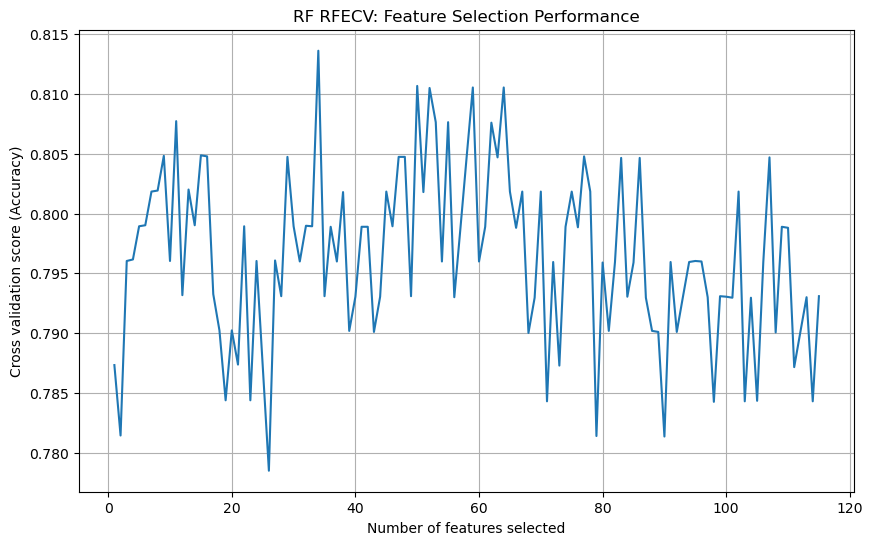

最佳特征数量: 38
选择的特征掩码: [False False  True False False False False  True False  True False False
 False  True  True False  True False False False False  True False  True
  True False  True  True  True False False  True  True  True False  True
  True  True  True  True  True  True  True  True  True  True  True False
  True  True False False False False False False False False False False
 False  True  True False False False False False False False False  True
 False False  True False False False  True False False False  True False
 False False False False False False False False False False False False
 False False False False False  True False  True False False False False
 False False False False False False False False False False  True]
特征排名: [26 16  1 57 54 35 28  1  5  1 64 46 15  1  1 27  1 13 31  8 81  1 22  1
  1 20  1  1  1 12 29  1  1  1 11  1  1  1  1  1  1  1  1  1  1  1  1  7
  1  1 33 38 51 59 66 47 49 61 71 48  2  1  1 50 37 18 78 56 40 34 10  1
 80 75  1 68 76 67  1 21 53  3

In [12]:
# 第一步：使用递归特征消除与交叉验证（RFECV）选择最佳特征
# 创建基础随机森林模型
base_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 创建5折交叉验证
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 创建RFECV对象
rfecv = RFECV(
    estimator=base_rf,
    step=1,  # 每次迭代移除一个特征
    cv=cv,
    scoring='accuracy',
    min_features_to_select=5,
    n_jobs=-1
)

# 执行递归特征消除
rfecv.fit(X_train, y_train)

# 绘制 RFECV 性能曲线
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (Accuracy)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.grid(True)
plt.title('RF RFECV: Feature Selection Performance')
plt.show()

# 输出特征选择结果
print(f"最佳特征数量: {rfecv.n_features_}")
print(f"选择的特征掩码: {rfecv.support_}")
print(f"特征排名: {rfecv.ranking_}")

# 获取选择的特征
X_train_selected = rfecv.transform(X_train)
X_test_selected = rfecv.transform(X_test)

In [13]:
# 第二步：网格搜索优化随机森林超参数
# 创建随机森林模型
rf = RandomForestClassifier(random_state=42)

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200, 300],  # 决策树数量
    'max_depth': [None, 10, 20, 30],      # 树的最大深度
    'min_samples_split': [2, 5, 10],      # 分裂内部节点所需的最小样本数
    'min_samples_leaf': [1, 2, 4],        # 叶节点所需的最小样本数
    'max_features': ['sqrt', 'log2']      # 构建树时考虑的特征数量
}


# 五折交叉验证结合网格搜索寻找最优参数
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,               # 五折交叉验证
    n_jobs=-1,          # 使用所有可用的CPU
    verbose=1,          # 输出搜索过程信息
    scoring='accuracy'  # 以准确率作为评分标准
)

# 在训练集上执行网格搜索
grid_search.fit(X_train_selected, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='accuracy', verbose=1)

In [14]:
# 输出最佳参数
print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证分数: {grid_search.best_score_:.4f}")

最佳参数: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
最佳交叉验证分数: 0.8338


In [15]:
# 第三步：使用最佳参数训练最终模型
# 使用最佳参数创建模型
best_rf = grid_search.best_estimator_

# 在训练集上训练最终模型
best_rf.fit(X_train_selected, y_train)

RandomForestClassifier(max_features='log2', min_samples_split=10,
                       n_estimators=300, random_state=42)

In [16]:
# 第四步：模型评估
# 预测
y_pred = best_rf.predict(X_test_selected)
y_pred_proba = best_rf.predict_proba(X_test_selected)

# 计算评估指标
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"测试集准确率: {accuracy:.4f}")
print(f"精确率: {precision:.4f}")
print(f"召回率: {recall:.4f}")
print(f"F1分数: {f1:.4f}")

# 交叉验证评估
cv_scores = cross_val_score(best_rf, X_train_selected, y_train, cv=cv, scoring='accuracy')
print(f"交叉验证准确率: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# 详细分类报告
print("\n分类报告:")
print(classification_report(y_test, y_pred,digits=4))

测试集准确率: 0.8163
精确率: 0.8056
召回率: 0.8163
F1分数: 0.7988
交叉验证准确率: 0.8194 (±0.0393)

分类报告:
              precision    recall  f1-score   support

         0.0     0.8320    0.9455    0.8851       110
         1.0     0.7273    0.4324    0.5424        37

    accuracy                         0.8163       147
   macro avg     0.7796    0.6889    0.7137       147
weighted avg     0.8056    0.8163    0.7988       147



In [18]:
# 打印混淆矩阵（可选）
print("\n混淆矩阵 (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))


混淆矩阵 (Confusion Matrix):
[[104   6]
 [ 21  16]]


In [17]:
###保存预测概率
# 对于二分类问题，我们通常需要正类的概率
y_pred_proba_best_rf = y_pred_proba[:, 1]

# 保存结果
# 建议将真实标签也一起保存，虽然它们应该是相同的，但这样更保险
results_best_rf = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba_best_rf': y_pred_proba_best_rf
})

# 将结果保存到一个CSV文件
results_best_rf.to_csv('D:\\AAA科研——高老师\\AML-论文撰写资料\\model1_results.csv', index=False)
print("rf results exported successfully.")

rf results exported successfully.


In [16]:
# 第五步：特征重要性分析
# 获取特征重要性
feature_importance = best_rf.feature_importances_

# 获取被选中的原始特征索引
selected_feature_indices = np.where(rfecv.support_)[0]

actual_feature_names = [
    'MolWt',
    'NumAtoms',
    'NumBonds',
    'NumHAcceptors',
    'NumHDonors',
    'NumRotatableBonds',
    'TPSA',
    'ExactMolWt',
    'FractionCSP3',
    'MolLogP',
    'NumAromaticRings',
    'NumSaturatedRings',
    'NumHeavyAtoms',
    'MaxEStateIndex',
    'MinEStateIndex',
    'MaxAbsEStateIndex',
    'MinAbsEStateIndex',
    'qed',
    'HeavyAtomMolWt',
    'NumValenceElectrons',
    'NumRadicalElectrons',
    'FpDensityMorgan1',
    'FpDensityMorgan2',
    'FpDensityMorgan3',
    'BCUT2D_MWHI',
    'BCUT2D_MWLOW',
    'BCUT2D_CHGHI',
    'BCUT2D_CHGLO',
    'BCUT2D_LOGPHI',
    'BCUT2D_LOGPLOW',
    'BCUT2D_MRHI',
    'BCUT2D_MRLOW',
    'BalabanJ',
    'BertzCT',
    'Chi0',
    'Chi0n',
    'Chi0v',
    'Chi1',
    'Chi1n',
    'Chi1v',
    'Chi2n',
    'Chi2v',
    'Chi3n',
    'Chi3v',
    'Chi4n',
    'Chi4v',
    'Kappa1',
    'Kappa2',
    'Kappa3',
    'LabuteASA',
    'PEOE_VSA1',
    'PEOE_VSA10',
    'PEOE_VSA11',
    'PEOE_VSA12',
    'PEOE_VSA13',
    'PEOE_VSA14',
    'PEOE_VSA2',
    'PEOE_VSA3',
    'PEOE_VSA4',
    'PEOE_VSA5',
    'PEOE_VSA6',
    'PEOE_VSA7',
    'PEOE_VSA8',
    'PEOE_VSA9',
    'SMR_VSA1',
    'SMR_VSA10',
    'SMR_VSA2',
    'SMR_VSA3',
    'SMR_VSA4',
    'SMR_VSA5',
    'SMR_VSA6',
    'SMR_VSA7',
    'SMR_VSA8',
    'SMR_VSA9',
    'SlogP_VSA1',
    'SlogP_VSA10',
    'SlogP_VSA11',
    'SlogP_VSA12',
    'SlogP_VSA2',
    'SlogP_VSA3',
    'SlogP_VSA4',
    'SlogP_VSA5',
    'SlogP_VSA6',
    'SlogP_VSA7',
    'SlogP_VSA8',
    'SlogP_VSA9',
    'EState_VSA1',
    'EState_VSA10',
    'EState_VSA11',
    'EState_VSA2',
    'EState_VSA3',
    'EState_VSA4',
    'EState_VSA5',
    'EState_VSA6',
    'EState_VSA7',
    'EState_VSA8',
    'EState_VSA9',
    'VSA_EState1',
    'VSA_EState10',
    'VSA_EState2',
    'VSA_EState3',
    'VSA_EState4',
    'VSA_EState5',
    'VSA_EState6',
    'VSA_EState7',
    'VSA_EState8',
    'VSA_EState9',
    'NHOHCount',
    'NOCount',
    'NumAliphaticCarbocycles',
    'NumAliphaticHeterocycles',
    'NumAliphaticRings',
    'NumAromaticCarbocycles',
    'NumAromaticHeterocycles',
    'NumHeteroatoms',
    'NumSaturatedCarbocycles',
    'NumSaturatedHeterocycles',
    'NumSaturatedRings',
    'RingCount',
    'MolMR'
]

# 获取被选中的特征名称
selected_feature_names = [actual_feature_names[i] for i in selected_feature_indices]

# 创建特征重要性 DataFrame
importance_df = pd.DataFrame({
    'feature': selected_feature_names,  # 使用实际特征名称
    'importance': feature_importance,
    'original_index': selected_feature_indices  # 保存原始索引
})


# 设置英文字体（全局设置）
plt.rcParams['font.family'] = 'Arial'  # 或者 'Helvetica', 'DejaVu Sans'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

# 初始化SHAP解释器
# 使用TreeExplainer，因为它适用于树型模型（如随机森林、XGBoost等）
explainer = shap.TreeExplainer(best_rf, X_train_selected)
shap_values = explainer.shap_values(X_test_selected)

print(f"shap_values shape: {np.array(shap_values).shape}")
print(f"Data X shape: {X_test_selected.shape}")

# 确保数据类型一致
print(f"X type: {type(X_test_selected)}")
print(f"shap_values type: {type(shap_values)}")
print(f"importance_df type:{type(importance_df)}")


shap_values shape: (147, 58, 2)
Data X shape: (147, 58)
X type: <class 'numpy.ndarray'>
shap_values type: <class 'numpy.ndarray'>
importance_df type:<class 'pandas.core.frame.DataFrame'>


In [17]:
# 生成并保存图表
# 对于分类模型，shap_values通常是一个列表，每个类别对应一组值。
# 本例是二分类，我们取第1类（恶性）的SHAP值进行分析，通常这代表"正类"或我们感兴趣的类别。
# 如果你的模型是回归模型，直接使用 `shap_values = explainer.shap_values(X_test)` 即可。
shap_values_to_plot = shap_values[:, :, 1]  # 形状变为 (147, 58)
feature_names=importance_df["feature"]
print(feature_names)
print(shap_values_to_plot)
print(importance_df)

0                   MolWt
1                NumAtoms
2                NumBonds
3              ExactMolWt
4                 MolLogP
5           NumHeavyAtoms
6          MaxEStateIndex
7          MinEStateIndex
8       MinAbsEStateIndex
9     NumValenceElectrons
10       FpDensityMorgan1
11       FpDensityMorgan2
12       FpDensityMorgan3
13            BCUT2D_MWHI
14           BCUT2D_MWLOW
15           BCUT2D_CHGHI
16           BCUT2D_CHGLO
17          BCUT2D_LOGPHI
18         BCUT2D_LOGPLOW
19           BCUT2D_MRLOW
20               BalabanJ
21                BertzCT
22                   Chi0
23                  Chi0n
24                  Chi0v
25                   Chi1
26                  Chi1n
27                  Chi1v
28                  Chi2n
29                  Chi2v
30                  Chi3n
31                  Chi3v
32                  Chi4n
33                  Chi4v
34                 Kappa1
35                 Kappa2
36                 Kappa3
37              LabuteASA
38          

In [18]:
# a) 柱状图 - 特征重要性的全局摘要
# 使用每个特征的平均绝对SHAP值来衡量重要性
# 设置全局样式 - 让图表更美观
plt.style.use('default')  # 使用默认样式，或者尝试 'seaborn-v0_8', 'seaborn-v0_8-whitegrid'

# 创建图形
plt.figure(figsize=(10, 8))

# 绘制SHAP条形图
shap.summary_plot(shap_values_to_plot, 
                  feature_names=feature_names, 
                  plot_type="bar", 
                  show=False,
                  max_display=15)  # 限制显示的特征数量，避免过于拥挤

# 获取当前轴对象
ax = plt.gca()

# 1. 美化颜色 - 使用渐变色或更专业的配色
# 获取条形图的矩形对象
bars = ax.containers[0]
# 创建颜色渐变（从深蓝色到浅蓝色）
colors = plt.cm.Blues(np.linspace(0.6, 0.9, len(bars)))
# 或者使用其他配色方案：
# colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(bars)))  # 紫绿色渐变
# colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(bars)))   # 等离子色渐变

# 为每个条形设置颜色
for bar, color in zip(bars, colors):
    bar.set_color(color)
    bar.set_edgecolor('black')  # 添加黑色边框
    bar.set_linewidth(0.5)      # 边框线宽
    bar.set_alpha(0.8)          # 稍微透明

# 2. 添加数值标签
# 在每个条形末端显示具体的SHAP值
for bar in bars:
    width = bar.get_width()
    ax.text(width + width * 0.01,  # x位置：条形宽度 + 小偏移
            bar.get_y() + bar.get_height() / 2,  # y位置：条形中间
            f'{width:.4f}',  # 显示4位小数
            va='center', ha='left', fontsize=10, fontweight='bold')

# 3. 美化坐标轴和网格
ax.spines['top'].set_visible(False)    # 移除上边框
ax.spines['right'].set_visible(False)  # 移除右边框
ax.spines['left'].set_linewidth(0.5)   # 左边框细线
ax.spines['bottom'].set_linewidth(0.5) # 底边框细线

# 添加网格线（只在x轴方向）
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)

# 4. 调整标签和标题
plt.xlabel('mean(|SHAP value|) ', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Features', fontsize=12, fontweight='bold', labelpad=10)


# 5. 调整刻度标签
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 6. 调整布局和保存
plt.tight_layout()

# 保存为高质量图片
plt.savefig('RF-shap_bar_plot.png', 
            dpi=300, 
            bbox_inches='tight',
            facecolor='white',  # 确保背景为白色
            edgecolor='none')   # 无边框



plt.close()

print("美观的SHAP特征重要性柱状图已保存！")


美观的SHAP特征重要性柱状图已保存！


In [19]:
# b) 蜂群图 - 展示特征值与SHAP值关系的全局摘要
# 先诊断SHAP值分布
shap_flat = shap_values_to_plot.flatten()
print(f"SHAP值符号分布 - 正值: {np.sum(shap_flat > 0)}, 负值: {np.sum(shap_flat < 0)}")

plt.figure(figsize=(12, 8))

# 尝试不同的colormap
colormap_options = ['RdBu', 'RdBu_r', 'coolwarm', 'bwr', 'seismic', 'viridis', 'plasma']

# 选择你喜欢的colormap
shap.summary_plot(shap_values_to_plot, 
                 feature_names=feature_names, 
                 features=X_test_selected,
                 cmap='RdBu_r',  # 红蓝对比
                 plot_type="dot", 
                 show=False,
                 max_display=20)


# 强制设置对称的颜色范围
max_abs = max(abs(np.min(shap_values_to_plot)), abs(np.max(shap_values_to_plot)))
plt.gca().collections[0].set_clim(vmin=-max_abs, vmax=max_abs)

plt.xlabel('SHAP value ', fontsize=12, fontweight='bold', labelpad=10)



plt.tight_layout()
plt.savefig('RF-shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.close()

print("所有图表已保存完毕！")
print("-> RF-shap_summary_plot.png: 特征摘要蜂群图")

SHAP值符号分布 - 正值: 3029, 负值: 5497
所有图表已保存完毕！
-> RF-shap_summary_plot.png: 特征摘要蜂群图


In [20]:
#绘制ROC曲线图
y_pred_proba = best_rf.predict_proba(X_test_selected)[:, 1]

# 计算ROC曲线的假正例率(FPR)和真正例率(TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 计算ROC-AUC值
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC值: {roc_auc:.4f}")

# 绘制ROC曲线
plt.figure(figsize=(10, 8))
# 绘制随机森林的ROC曲线
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
# 绘制随机猜测的基准线（对角线）
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 设置图表属性
# 设置刻度标签字体
plt.xticks(fontfamily='Arial')
plt.yticks(fontfamily='Arial')
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate', fontfamily='Arial', fontsize=14)
plt.ylabel('True Positive Rate', fontfamily='Arial', fontsize=14)
plt.title('RF ROC Curve',fontfamily='Arial', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", prop={'family': 'Arial', 'size': 12})

# 5. 保存图片
plt.tight_layout()
plt.savefig('RF-roc_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()

ROC-AUC值: 0.7670
